## Wildfire Prediction Models
Khushi Khan, Ella Chee, Willbert Clement Christianto  
DS4420: Machine Learning and Data Mining 2

In [ ]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import keras
import tensorflow as tf

# keras contains the tensorflow package
from keras.models import Model
from keras.layers import Dense, Input, Rescaling
from keras.layers import Conv2D, MaxPooling2D, Flatten
from keras.losses import BinaryCrossentropy
from sklearn.metrics import ConfusionMatrixDisplay
from keras.optimizers import Adam

### Cleaning datasets (removing corrupted or truncated files)

In [5]:
# # Tracking all path files
data_root = Path("../../data/raw")
num_channels = 3

# def scan_dataset(directory):
#     bad_files = []
#     all_files = list(Path(directory).rglob("*.jpg")) + \
#                 list(Path(directory).rglob("*.jpeg")) + \
#                 list(Path(directory).rglob("*.png"))
    
#     print(f"Scanning {len(all_files)} files in {directory}...")
    
#     for path in all_files:
#         try:
#             with Image.open(path) as img:
#                 img.verify()
#             with Image.open(path) as img:
#                 img.load()
#         except Exception as e:
#             print(f"Bad file: {path} — {e}")
#             bad_files.append(path)
    
#     return bad_files

# bad_train = scan_dataset(data_root / "train")
# bad_test = scan_dataset(data_root / "test")
# bad_valid = scan_dataset(data_root / "valid")

# all_bad = bad_train + bad_test + bad_valid
# print(f"\nTotal bad files: {len(all_bad)}")

# for path in all_bad:
#     os.remove(path)
#     print(f"Removed: {path}")

In [6]:
# Load the images into a dataset
# - Infers subfolder labels (0 or 1)
# - Resizes images to (256, 256)
# - Color mode is RGB
# Documentation: https://keras.io/api/data_loading/image/
train_dataset = keras.utils.image_dataset_from_directory(Path(data_root / "train"), labels='inferred', shuffle=True)
test_dataset = keras.utils.image_dataset_from_directory(Path(data_root / "test"), labels='inferred')
valid_dataset = keras.utils.image_dataset_from_directory(Path(data_root / "valid"), labels='inferred')

Found 30249 files belonging to 2 classes.
Found 6299 files belonging to 2 classes.
Found 6300 files belonging to 2 classes.


In [7]:
# Checking that class names are correct
class_names = train_dataset.class_names
print(class_names)

['nowildfire', 'wildfire']


### Visualizing the training dataset and labels

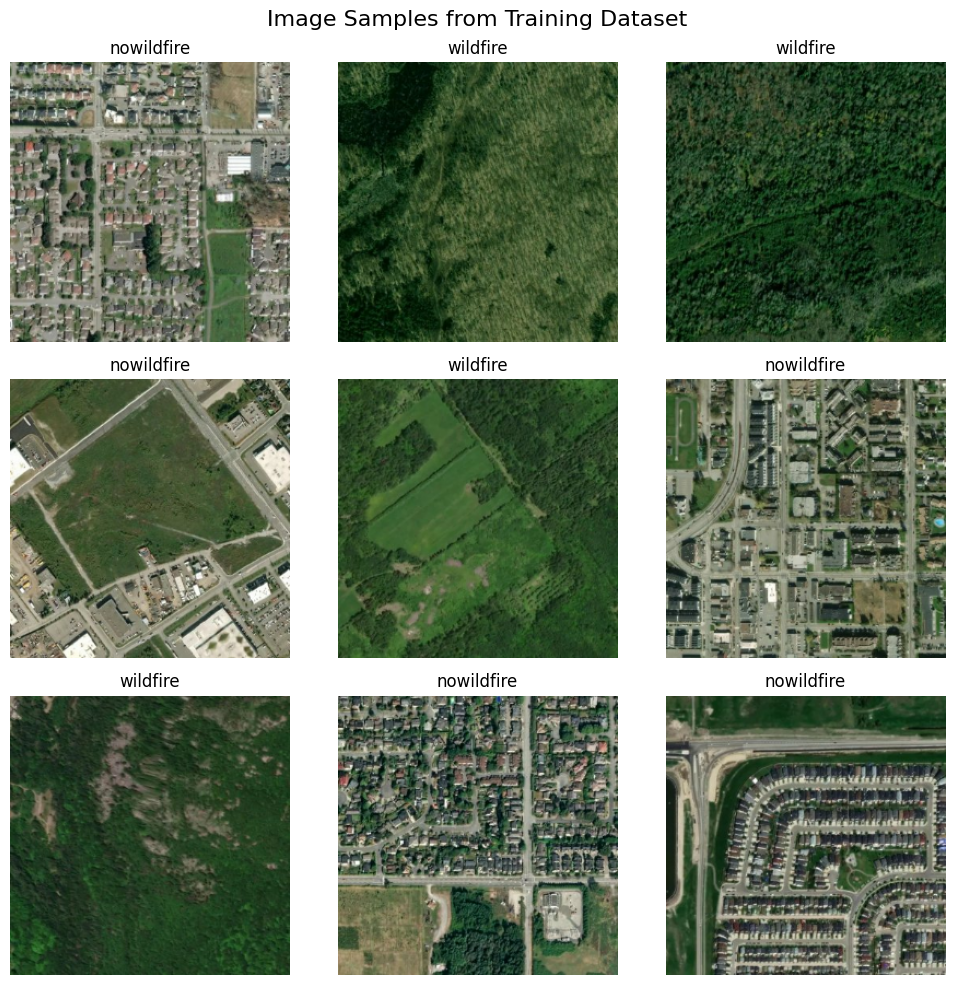

In [8]:
plt.figure(figsize=(10, 10))
plt.suptitle("Image Samples from Training Dataset", fontsize=16)
for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

### Inspecting tensor shapes

In [9]:
print(train_dataset.element_spec)
print(test_dataset.element_spec)
print(valid_dataset.element_spec)

(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))
(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))
(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))


In [10]:
# Configuring the dataset for performance
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
valid_dataset = valid_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

### Building the CNN

In [11]:
num_classes = len(class_names)

img_dim = (256, 256)

# Instantiating a Keras tensor
inpx = Input(shape=(img_dim[0], img_dim[1], num_channels))

# Normalizing the data to be between 0 and 1
inpx = Rescaling(1./255)(inpx)

# Instantiating first convolutional and pooling layer
conv_layer = Conv2D(16, kernel_size=(3,3), strides=1, activation='relu')(inpx)
pool_layer = MaxPooling2D(pool_size=(2,2))(conv_layer)

# Instantiating second convolutional and pooling layer
conv_layer2 = Conv2D(32, kernel_size=(3,3), strides=1, activation='relu')(pool_layer)
pool_layer2 = MaxPooling2D(pool_size=(2,2))(conv_layer2)

# Flattening the images for the hidden layer/output
flat_G = Flatten()(pool_layer2)

# Defining first hidden layer
hid_layer = Dense(64, activation='relu')(flat_G)

# Defining output layer
out_layer = Dense(1, activation='sigmoid')(hid_layer)

In [12]:
model = Model([inpx], out_layer)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=BinaryCrossentropy(),
    metrics=[
        'accuracy',
        keras.metrics.TruePositives(name='tp'),
        keras.metrics.FalsePositives(name='fp'),
        keras.metrics.TrueNegatives(name='tn'),
        keras.metrics.FalseNegatives(name='fn')
    ]
)

### Visualizing the layers of the CNN

In [13]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ keras_tensor_1CLONE             │ (None, 256, 256, 3)    │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 123008)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     7,872,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,877,729 (30.05 MB)

 Trainable params: 7,877,729 (30.05 MB)

 Non-trainable params: 0 (0.00 B)

### Training the CNN

In [14]:
epochs = 10

history = model.fit(
    train_dataset,
    batch_size=32,
    validation_data=valid_dataset,
    epochs=epochs
)

Epoch 1/10
946/946 ━━━━━━━━━━━━━━━━━━━━ 132s 123ms/step - accuracy: 0.8676 - fn: 1871.0000 - fp: 2135.0000 - loss: 5.8657 - tn: 12364.0000 - tp: 13879.0000 - val_accuracy: 0.9316 - val_fn: 232.0000 - val_fp: 199.0000 - val_loss: 0.1786 - val_tn: 2621.0000 - val_tp: 3248.0000
Epoch 2/10
946/946 ━━━━━━━━━━━━━━━━━━━━ 129s 137ms/step - accuracy: 0.9391 - fn: 590.0000 - fp: 1253.0000 - loss: 0.1586 - tn: 13246.0000 - tp: 15160.0000 - val_accuracy: 0.9425 - val_fn: 134.0000 - val_fp: 228.0000 - val_loss: 0.1544 - val_tn: 2592.0000 - val_tp: 3346.0000
Epoch 3/10
946/946 ━━━━━━━━━━━━━━━━━━━━ 134s 141ms/step - accuracy: 0.9541 - fn: 487.0000 - fp: 902.0000 - loss: 0.1289 - tn: 13597.0000 - tp: 15263.0000 - val_accuracy: 0.9298 - val_fn: 283.0000 - val_fp: 159.0000 - val_loss: 0.1958 - val_tn: 2661.0000 - val_tp: 3197.0000
Epoch 4/10
946/946 ━━━━━━━━━━━━━━━━━━━━ 141s 149ms/step - accuracy: 0.9586 - fn: 466.0000 - fp: 787.0000 - loss: 0.1202 - tn: 13712.0000 - tp: 15284.0000 - val_accuracy: 0.929

In [15]:
history.history.keys()

dict_keys(['accuracy', 'fn', 'fp', 'loss', 'tn', 'tp', 'val_accuracy', 'val_fn', 'val_fp', 'val_loss', 'val_tn', 'val_tp'])

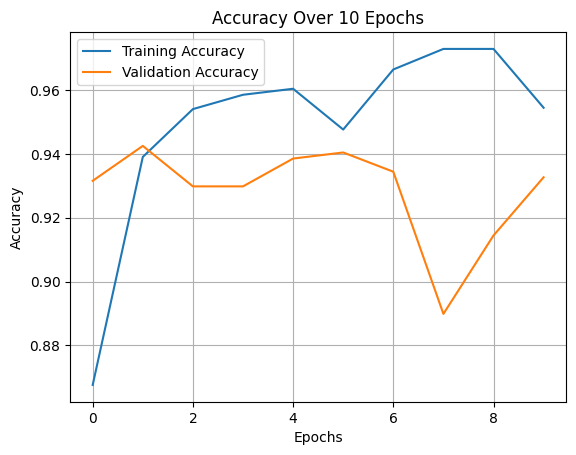

In [16]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title(f"Accuracy Over {epochs} Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

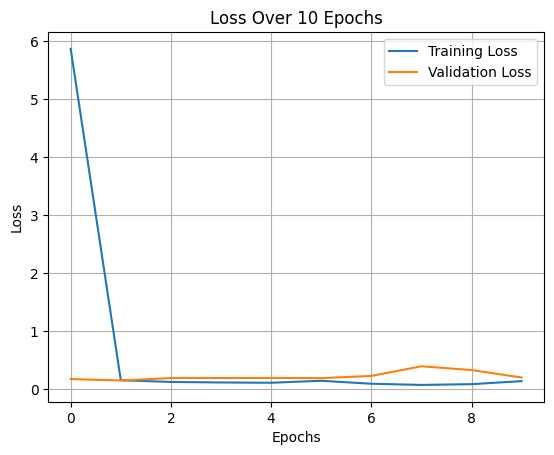

In [17]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title(f"Loss Over {epochs} Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

The plots indicate that the model is learning the data well. This is especially shown in the Loss plot, as the loss on the validation set converges converges to approximately 0.3. Additionally, the validation accuracy is high, oscillating between 88-94%.

### Evaluating the model's performance on the test data and examining performance metrics

In [18]:
score = model.evaluate(test_dataset)

model_metrics = {
    'Loss': round(score[0], 4),
    'Accuracy': round(score[1], 4),
    'True positives': score[2],
    'False positives': score[3],
    'True negatives': score[4],
    'False negatives': score[5]
}

for metric, score in model_metrics.items():
    print(f"{metric}: {score}")

197/197 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.9416 - fn: 191.0000 - fp: 177.0000 - loss: 0.1957 - tn: 2643.0000 - tp: 3288.0000
Loss: 0.1957
Accuracy: 0.9416
True positives: 3288.0
False positives: 177.0
True negatives: 2643.0
False negatives: 191.0


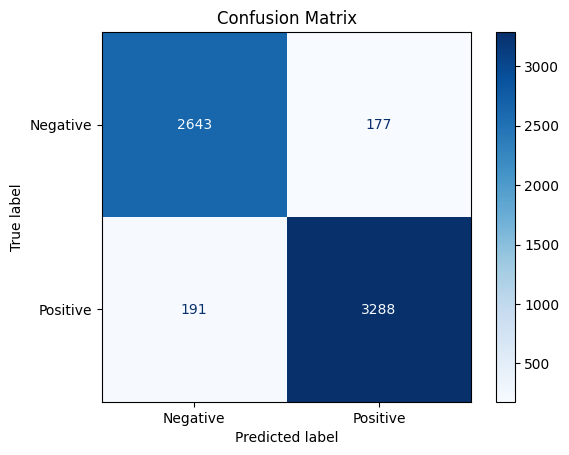

In [19]:
confusion_matrix = np.array([[model_metrics['True negatives'], model_metrics['False positives']],
                             [model_metrics['False negatives'], model_metrics['True positives']]])

disp = ConfusionMatrixDisplay(confusion_matrix, display_labels=['Negative', 'Positive'])
disp.plot(cmap='Blues', values_format='.0f')
plt.title('Confusion Matrix')
plt.show()

The model is performing quite well. The majority of its predictions are true positives and negatives, which means that it's able to detect wildfires and non-wildfires accurately. It has a high accuracy of 97% on the test dataset.

In [20]:
precision = model_metrics['True positives'] / (model_metrics['True positives'] + model_metrics['False positives'])
recall = model_metrics['True positives'] / (model_metrics['True positives'] + model_metrics['False negatives'])
f1_score = 2 * ((precision * recall) / (precision + recall))
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1_score}")

Precision: 0.9489177489177489
Recall: 0.9450991664271342
F1 Score: 0.9470046082949309


Precision measures the accuracy of positive predictions. The precision of 97% indicates that the model is predicting wildfires accurately and not detecting many false alarms. The high recall of 96% indicates that the model is not making many false negatives. It is adept at capturing the likelihood of wildfires, rarely missing any. The F1 score of 97% indicates that there is a good balance between precision and recall.

### Saving the model

In [21]:
try:
    model.save('./cnn_model.keras')
    print("Model saved!")
except Exception as e:
    print(f"Error while saving model: {e}")

# how to load the model back:
# model = keras.models.load_model('./cnn_model.keras')

Model saved!
